# Base CNN Training for Posture Classification (FP32)

## Imports

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Keras 3
import keras
import keras_tuner

# TensorFlow
import tensorflow as tf

# Package imports
from bedposip.data import load_dataset, preprocess_data
from bedposip.model import (
    create_model,
    get_callbacks,
    train_model,
)
from bedposip.utils import (
    check_layer_trainable_params,
    plot_training_history,
    class_report_metric,
    save_model,
)

# Configure matplotlib for PDF export with serif font
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Computer Modern Serif",
})

# Ensure figures directory exists
os.makedirs('figures', exist_ok=True)


I0000 00:00:1785038368.827378  260025 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Set random seed for reproducibility
np.random.seed(42)
keras.utils.set_random_seed(42)

# Constant number of postures
NUM_CLASSES = 3

# Check GPU
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Data

### Loading

In [3]:
# Load datasets using package function
X_train, y_train, X_val, y_val, X_test, y_test = load_dataset()


Dataset shapes:
  Train: (119999, 64), labels: (119999,)
  Val:   (60000, 64), labels: (60000,)
  Test:  (120001, 64), labels: (120001,)


### Preprocessing

In [4]:
# Preprocess data using package function
(X_train, y_train, X_val, y_val, X_test, y_test, class_names) = preprocess_data(
    X_train, y_train, X_val, y_val, X_test, y_test,
    num_classes=NUM_CLASSES,
)

Label encoding:
  lateral_L -> 0
  lateral_R -> 1
  supine -> 2

One-hot encoded shape: 3

Reshaped data:
  Train: (119999, 8, 8, 1)
  Val:   (60000, 8, 8, 1)
  Test:  (120001, 8, 8, 1)

Data range: [0.0000, 233.4754]
Data dtype: float32


## Configuration

In [5]:
# Define callbacks using package function
callbacks = get_callbacks(model_name='base', patience=10)

Callbacks configured:
  - EarlyStopping
  - ReduceLROnPlateau


## Base Model

In [6]:
# Create and inspect model
base_model = create_model(num_classes=NUM_CLASSES)
base_model.summary()

check_layer_trainable_params(base_model)

I0000 00:00:1785038372.330858  260025 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1033 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3070, pci bus id: 0000:10:00.0, compute capability: 8.6


Model: "posture_classifier_base"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ pressure_map (InputLayer)       │ (None, 8, 8, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_1 (Conv2D)                 │ (None, 6, 6, 16)       │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_conv_1 (BatchNormalization)  │ (None, 6, 6, 16)       │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_act_1 (Activation)         │ (None, 6, 6, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 4, 4, 16)       │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_conv_2 (BatchNormalization)  │ (None, 4, 4, 16)       │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_act_2 (Activation)         │ (None, 4, 4, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_3 (Conv2D)                 │ (None, 2, 2, 24)       │         3,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_conv_3 (BatchNormalization)  │ (None, 2, 2, 24)       │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_act_3 (Activation)         │ (None, 2, 2, 24)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 1, 1, 24)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 42)             │         1,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_dense_1 (BatchNormalization) │ (None, 42)             │           168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 42)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_dense_2 (BatchNormalization) │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,443 (40.79 KB)

 Trainable params: 10,119 (39.53 KB)

 Non-trainable params: 324 (1.27 KB)

conv_1: 144
conv_2: 2304
conv_3: 3456
dense_1: 1008
dense_2: 2688
output: 192


### Training

Epoch 1/50


I0000 00:00:1785038374.502385  260094 service.cc:153] XLA service 0x7f4b4003c3e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1785038374.502398  260094 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3070, Compute Capability 8.6 (Driver: 13.3.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.21.1)
I0000 00:00:1785038374.550542  260094 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1785038374.835149  260094 cuda_dnn.cc:461] Loaded cuDNN version 92101
I0000 00:00:1785038374.855604  260094 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3781__.53


  66/3750 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.4655 - loss: 1.1156

I0000 00:00:1785038379.562702  260094 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


3719/3750 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7128 - loss: 0.6594

I0000 00:00:1785038384.922192  260092 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3781__.53


3750/3750 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - accuracy: 0.7794 - loss: 0.5312 - val_accuracy: 0.8451 - val_loss: 0.3903 - learning_rate: 0.0010
Epoch 2/50
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8494 - loss: 0.3812 - val_accuracy: 0.8577 - val_loss: 0.3594 - learning_rate: 0.0010
Epoch 3/50
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8688 - loss: 0.3355 - val_accuracy: 0.8839 - val_loss: 0.3006 - learning_rate: 0.0010
Epoch 4/50
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8802 - loss: 0.3081 - val_accuracy: 0.8899 - val_loss: 0.2867 - learning_rate: 0.0010
Epoch 5/50
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8886 - loss: 0.2897 - val_accuracy: 0.8938 - val_loss: 0.2721 - learning_rate: 0.0010
Epoch 6/50
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8932 - loss: 0.2768 - val_accuracy: 0.8966 - val_loss: 0.2674 - learning_rate: 0.0010
Epoch 7/50
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8978 - loss: 0.266

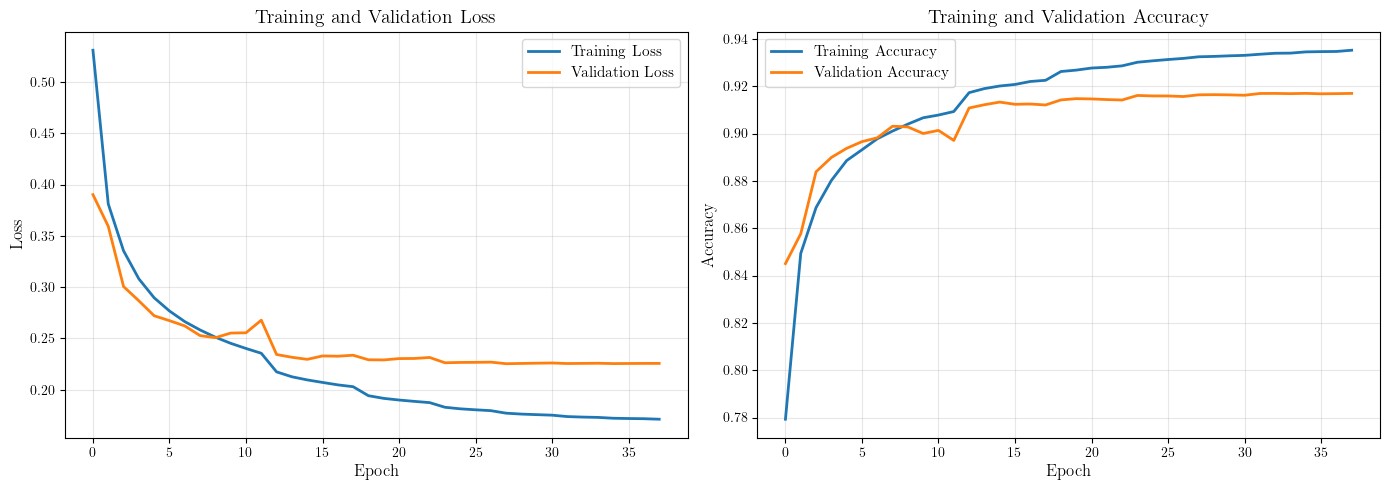

In [7]:
# Train the model
base_history = train_model(
    base_model, X_train, y_train, X_val, y_val, callbacks,
    batch_size=32, epochs=50,
)
plot_training_history(base_history, model_name='posture_classifier_base', save=True)

## Tuned Model

Hyperparameter optimization (KerasTuner)

In [8]:
tuner = keras_tuner.Hyperband(
    hypermodel=create_model,
    objective='val_accuracy',
    max_epochs=10,
    factor=3,
    hyperband_iterations=2,
    overwrite=True,
    directory='tuning',
    project_name='posture_cnn',
    )

tuner.search_space_summary()

Search space summary
Default search space size: 6
filters_1 (Int)
{'default': None, 'conditions': [], 'min_value': 4, 'max_value': 32, 'step': 4, 'sampling': 'linear'}
filters_2 (Int)
{'default': None, 'conditions': [], 'min_value': 4, 'max_value': 32, 'step': 4, 'sampling': 'linear'}
filters_3 (Int)
{'default': None, 'conditions': [], 'min_value': 8, 'max_value': 48, 'step': 4, 'sampling': 'linear'}
densefilters_1 (Int)
{'default': None, 'conditions': [], 'min_value': 2, 'max_value': 64, 'step': 4, 'sampling': 'linear'}
densefilters_2 (Int)
{'default': None, 'conditions': [], 'min_value': 2, 'max_value': 64, 'step': 4, 'sampling': 'linear'}
learning_rate (Choice)
{'default': 0.001, 'conditions': [], 'values': [0.001, 0.0001], 'ordered': True}


In [9]:
tuner.search(X_train, y_train, epochs=10, validation_data=(X_val, y_val))
tuned_model = tuner.get_best_models()[0]

tuned_model.summary()

check_layer_trainable_params(tuned_model)

Trial 60 Complete [00h 01m 35s]
val_accuracy: 0.900950014591217

Best val_accuracy So Far: 0.9137166738510132
Total elapsed time: 00h 40m 03s


Model: "posture_classifier_tuned"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ pressure_map (InputLayer)       │ (None, 8, 8, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_1 (Conv2D)                 │ (None, 6, 6, 24)       │           216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_conv_1 (BatchNormalization)  │ (None, 6, 6, 24)       │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_act_1 (Activation)         │ (None, 6, 6, 24)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 4, 4, 20)       │         4,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_conv_2 (BatchNormalization)  │ (None, 4, 4, 20)       │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_act_2 (Activation)         │ (None, 4, 4, 20)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_3 (Conv2D)                 │ (None, 2, 2, 36)       │         6,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_conv_3 (BatchNormalization)  │ (None, 2, 2, 36)       │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_act_3 (Activation)         │ (None, 2, 2, 36)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 1, 1, 36)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 26)             │           936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_dense_1 (BatchNormalization) │ (None, 26)             │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 26)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           260 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_dense_2 (BatchNormalization) │ (None, 10)             │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,709 (49.64 KB)

 Trainable params: 12,477 (48.74 KB)

 Non-trainable params: 232 (928.00 B)

conv_1: 216
conv_2: 4320
Layer conv_2 is too large (4320), are you sure you want to train?
conv_3: 6480
Layer conv_3 is too large (6480), are you sure you want to train?
dense_1: 936
dense_2: 260
output: 30


### Training

Epoch 1/50


I0000 00:00:1785041078.047445  260090 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_6555105__.53


3743/3750 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9188 - loss: 0.2120

I0000 00:00:1785041085.628421  260094 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_6555105__.53


3750/3750 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - accuracy: 0.9198 - loss: 0.2111 - val_accuracy: 0.9153 - val_loss: 0.2279 - learning_rate: 0.0010
Epoch 2/50
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.9219 - loss: 0.2056 - val_accuracy: 0.9126 - val_loss: 0.2386 - learning_rate: 0.0010
Epoch 3/50
3736/3750 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9229 - loss: 0.2011
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.9234 - loss: 0.2010 - val_accuracy: 0.9089 - val_loss: 0.2539 - learning_rate: 0.0010
Epoch 4/50
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.9320 - loss: 0.1826 - val_accuracy: 0.9220 - val_loss: 0.2166 - learning_rate: 5.0000e-04
Epoch 5/50
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.9345 - loss: 0.1767 - val_accuracy: 0.9219 - val_loss: 0.2187 - learning_rate: 5.0000e-04
Epoch 6/50
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.9360 - loss

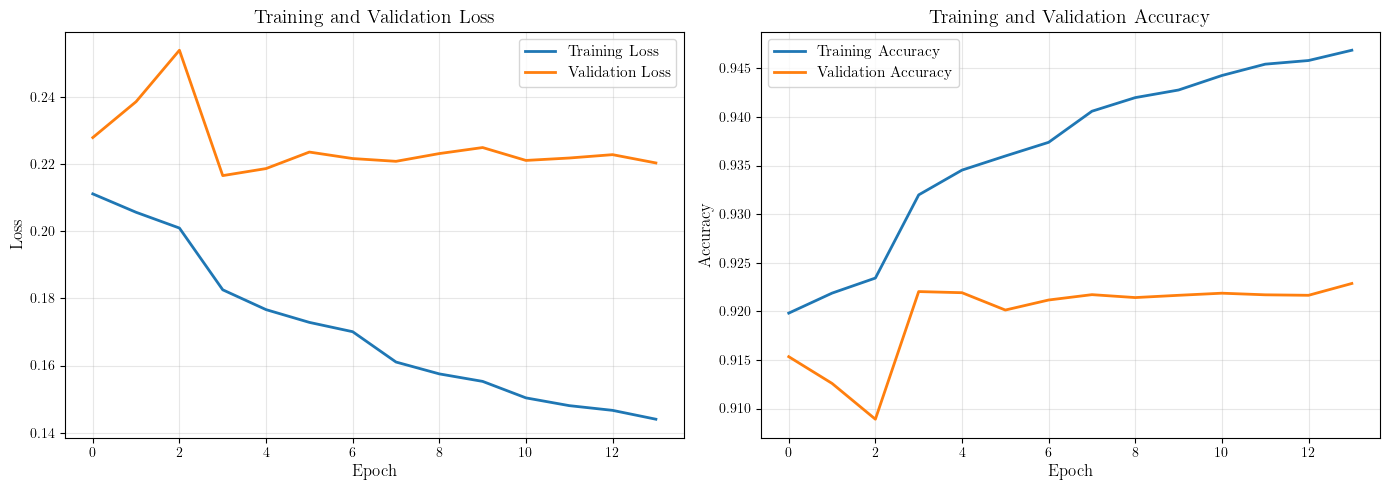

In [10]:
tuned_history = train_model(tuned_model, X_train, y_train, X_val, y_val, callbacks)
plot_training_history(tuned_history, model_name='posture_classifier_tuned', save=True)

## Model Evaluation

### Base Model


Accuracy Report for `posture_classifier_base`:
  Loss: 0.2259
  Accuracy: 91.56%

Classification Report for `posture_classifier_base`:
              precision    recall  f1-score   support

   lateral_L     0.9167    0.9107    0.9137     40000
   lateral_R     0.9061    0.9211    0.9135     40000
      supine     0.9244    0.9151    0.9197     40001

    accuracy                         0.9156    120001
   macro avg     0.9157    0.9156    0.9156    120001
weighted avg     0.9157    0.9156    0.9156    120001

Saved: figures/cm_posture_classifier_base.pdf


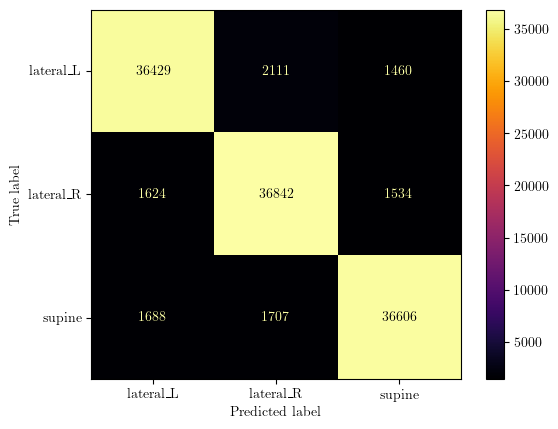

In [11]:
# Classification report for base model
class_report_metric(base_model, X_test, y_test, class_names, save=True)

### Tuned Model


Accuracy Report for `posture_classifier_tuned`:
  Loss: 0.2200
  Accuracy: 92.00%

Classification Report for `posture_classifier_tuned`:
              precision    recall  f1-score   support

   lateral_L     0.9281    0.9111    0.9196     40000
   lateral_R     0.9039    0.9322    0.9178     40000
      supine     0.9287    0.9166    0.9226     40001

    accuracy                         0.9200    120001
   macro avg     0.9202    0.9200    0.9200    120001
weighted avg     0.9202    0.9200    0.9200    120001

Saved: figures/cm_posture_classifier_tuned.pdf


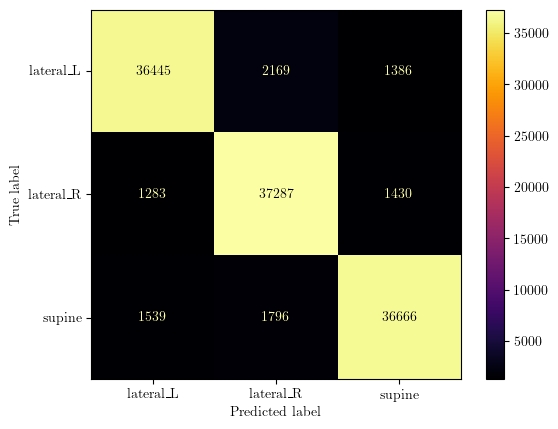

In [12]:
# Classification report for tuned model
class_report_metric(tuned_model, X_test, y_test, class_names, save=True)

## Model Saving

In [13]:
# Save models
save_model(base_model, output_dir='output')
save_model(tuned_model, output_dir='output')


Model saved to: output/posture_classifier_base.keras

Verification:
  Loaded successfully: True
  Model name: posture_classifier_base
  Total parameters: 10,443

Model saved to: output/posture_classifier_tuned.keras

Verification:
  Loaded successfully: True
  Model name: posture_classifier_tuned
  Total parameters: 12,709
